## Import Libraries

In [233]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc

from sentence_transformers import SentenceTransformer

import time

In [211]:
# Run once

import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vishalbhaga/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vishalbhaga/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vishalbhaga/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/vishalbhaga/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [212]:
# Time decorator
def get_time(func):
    def wrapper():
        start_time = time.perf_counter()
        func()
        end_time = time.perf_counter()
        runtime = end_time - start_time
        print(f'{runtime} s')
    return wrapper

## Load the Data

In [213]:
def load_data(folder_path):
    texts = []
    labels = []
    path_names = []

    for label in ['pos', 'neg']:
        for file_path in Path(folder_path, label).glob("*.txt"):
            texts.append(file_path.read_text(encoding='latin-1'))       # handles characters that break UTF-8
            labels.append(1 if label == 'pos' else 0)
            path_names.append(str(file_path))
    
    return [texts, labels, path_names]

In [214]:
input_data = load_data("review_polarity/txt_sentoken")

df = pd.DataFrame({
    "text": input_data[0],
    "label": input_data[1]
})

df.head()

,text,label
0,assume nothing . \nthe phrase is perhaps one o...,1
1,plot : derek zoolander is a male model . \nhe ...,1
2,i actually am a fan of the original 1961 or so...,1
3,a movie that's been as highly built up as the ...,1
4,""" good will hunting "" is two movies in one : ...",1


In [215]:
df['label'].value_counts()

label
1    1000
0    1000
Name: count, dtype: int64

## Data Preprocessing

In [216]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Custom function to handle common parts of speech
def get_part_of_speech(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def pre_processing(text):
    # Lowercasing
    text = text.lower()

    # Tokenisation - split text into words
    words = word_tokenize(text)

    # Remove Stopwords - remove common words such as "I", "am" etc
    words = [w for w in words if w not in stop_words]

    # Lemmatisation - reduce words to base form
    # By default only works on nouns
    tagged = pos_tag(words)
    words = [
        lemmatizer.lemmatize(word, get_part_of_speech(tag))
        for word, tag in tagged
    ]

    return " ".join(words)

In [217]:
df["pre_processed"] = df["text"].apply(pre_processing)

In [218]:
df.head()

,text,label,pre_processed
0,assume nothing . \nthe phrase is perhaps one o...,1,assume nothing . phrase perhaps one use 1990 '...
1,plot : derek zoolander is a male model . \nhe ...,1,plot : derek zoolander male model . also dumb ...
2,i actually am a fan of the original 1961 or so...,1,actually fan original 1961 live-action-disney ...
3,a movie that's been as highly built up as the ...,1,"movie 's highly build truman show , review boa..."
4,""" good will hunting "" is two movies in one : ...",1,`` good hunting `` two movie one : independent...


In [219]:
# Split data into train, validation and test sets

X = df['pre_processed']
y = df['label']

# First split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Second split: Split the 30% Temp into two 15% sets (Val and Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [220]:
# Check class counts in each split
print(f'Train set class count: \n{pd.Series(y_train).value_counts()}')
print(f'Validation set class count: \n{pd.Series(y_val).value_counts()}')
print(f'Test set class count: \n{pd.Series(y_test).value_counts()}')

Train set class count: 
label
0    700
1    700
Name: count, dtype: int64
Validation set class count: 
label
1    150
0    150
Name: count, dtype: int64
Test set class count: 
label
1    150
0    150
Name: count, dtype: int64


## Make Model

In [221]:
def make_model(svm_type = 'linear', penalty = 'l2', C=1, gamma='scale'):
    if svm_type == 'rbf':
        model = SVC(kernel='rbf', C=C, gamma=gamma)
    else:
        model = LinearSVC(penalty=penalty, C=C)
    
    pipeline = Pipeline([
        ('featExtr', TfidfVectorizer()),
        ('model', model)
    ])

    return pipeline

## Feature Extraction Analysis

In [222]:
model = make_model()

model.fit(X_train, y_train)
tfidf = model.named_steps['featExtr']

vocabulary_size = len(tfidf.vocabulary_)
print("Vocabulary size:", vocabulary_size)

print("Max DF:", tfidf.max_df)

X_train_tfidf = tfidf.transform(X_train)
print(X_train_tfidf.shape)

Vocabulary size: 29250
Max DF: 1.0
(1400, 29250)


In [223]:
# model = SentenceTransformer("all-MiniLM-L6-v2")

# X_train_embeddings = model.encode(X_train, show_progress_bar=True)

# print(X_train_embeddings.shape)

## SVM Training with Regularisation

In [224]:
# i) Linear SVM with L2 regularisation, C = 1.0

model = make_model(svm_type = 'linear', penalty = 'l2')

start_time = time.perf_counter()

model.fit(X_train, y_train)

end_time = time.perf_counter()
runtime = end_time - start_time
print(f'Runtime: {runtime} s')

y_val_pred = model.predict(X_val)
f1_val = f1_score(y_val, y_val_pred)
auc_val = roc_auc_score(y_val, y_val_pred)

print(f'Validation F1-Score: {f1_val}')
print(f'Validation AUC_ROC-Score: {auc_val}')

Runtime: 0.13394633299958514 s
Validation F1-Score: 0.8403908794788274
Validation AUC_ROC-Score: 0.8366666666666667


In [225]:
# ii) Linear SVM with L1 regularisation, C = 1.0

model = make_model(svm_type = 'linear', penalty = 'l1')

start_time = time.perf_counter()

model.fit(X_train, y_train)

end_time = time.perf_counter()
runtime = end_time - start_time
print(f'Runtime: {runtime} s')

y_val_pred = model.predict(X_val)
f1_val = f1_score(y_val, y_val_pred)
auc_val = roc_auc_score(y_val, y_val_pred)

print(f'Validation F1-Score: {f1_val}')
print(f'Validation AUC_ROC-Score: {auc_val}')

Runtime: 0.14189220900061628 s
Validation F1-Score: 0.8438538205980066
Validation AUC_ROC-Score: 0.8433333333333333


In [226]:
# iii) Linear SVM with L2 regularisation, C ∈ {0.01, 0.1, 1, 10, 100} 

C_values = [0.01, 0.1, 1, 10, 100]

results = []

for C in C_values:
    print(f'C = {C}')

    model = make_model(svm_type = 'linear', penalty = 'l2', C=C)

    start_time = time.perf_counter()

    model.fit(X_train, y_train)

    end_time = time.perf_counter()
    runtime = end_time - start_time
    print(f'Runtime: {runtime} s')

    y_val_pred = model.predict(X_val)
    f1_val = f1_score(y_val, y_val_pred)
    auc_val = roc_auc_score(y_val, y_val_pred)

    print(f'Validation F1-Score: {f1_val}')
    print(f'Validation AUC_ROC-Score: {auc_val} \n')

    results.append((C, f1_val))

best_C, best_f1 = max(results, key=lambda x: x[1])

print("Best C:", best_C)
print("Best F1:", best_f1)

C = 0.01
Runtime: 0.11371537500053819 s
Validation F1-Score: 0.7894736842105263
Validation AUC_ROC-Score: 0.7866666666666666 

C = 0.1
Runtime: 0.11497624999992695 s
Validation F1-Score: 0.8300653594771242
Validation AUC_ROC-Score: 0.8266666666666667 

C = 1
Runtime: 0.12113216699981422 s
Validation F1-Score: 0.8403908794788274
Validation AUC_ROC-Score: 0.8366666666666667 

C = 10
Runtime: 0.17521250000027067 s
Validation F1-Score: 0.8431372549019608
Validation AUC_ROC-Score: 0.8400000000000001 

C = 100
Runtime: 0.14154620800036355 s
Validation F1-Score: 0.8382838283828383
Validation AUC_ROC-Score: 0.8366666666666667 

Best C: 10
Best F1: 0.8431372549019608


In [227]:
# iv) RBF kernel SVM with optimal C from (iii) and γ ∈ {scale, auto, 0.001, 0.01} 

gamma_values = ['scale', 'auto', 0.001, 0.01]

results = []

for gamma in gamma_values:
    print(f'gamma = {gamma}')

    model = make_model(svm_type = 'rbf', C=best_C, gamma=gamma)

    start_time = time.perf_counter()

    model.fit(X_train, y_train)

    end_time = time.perf_counter()
    runtime = end_time - start_time
    print(f'Runtime: {runtime} s')

    y_val_pred = model.predict(X_val)
    f1_val = f1_score(y_val, y_val_pred)
    auc_val = roc_auc_score(y_val, y_val_pred)

    print(f'Validation F1-Score: {f1_val}')
    print(f'Validation AUC_ROC-Score: {auc_val} \n')

    results.append((gamma, f1_val))

best_gamma, best_f1 = max(results, key=lambda x: x[1])

print("Best gamma:", best_gamma)
print("Best F1:", best_f1)

gamma = scale
Runtime: 2.097677540999939 s
Validation F1-Score: 0.8262295081967214
Validation AUC_ROC-Score: 0.8233333333333333 

gamma = auto
Runtime: 2.0494377079994592 s
Validation F1-Score: 0.7747252747252747
Validation AUC_ROC-Score: 0.7266666666666666 

gamma = 0.001
Runtime: 2.0667135000003327 s
Validation F1-Score: 0.7747252747252747
Validation AUC_ROC-Score: 0.7266666666666666 

gamma = 0.01
Runtime: 2.0351510000000417 s
Validation F1-Score: 0.7987804878048781
Validation AUC_ROC-Score: 0.78 

Best gamma: scale
Best F1: 0.8262295081967214


## Evaluation

In [228]:
# Best model = (ii)
model = make_model(svm_type = 'linear', penalty = 'l1')
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

In [ ]:
# Classification report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.81      0.76      0.78       150
           1       0.77      0.82      0.80       150

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



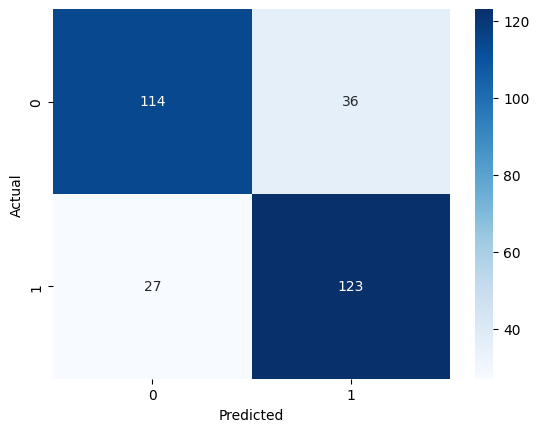

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

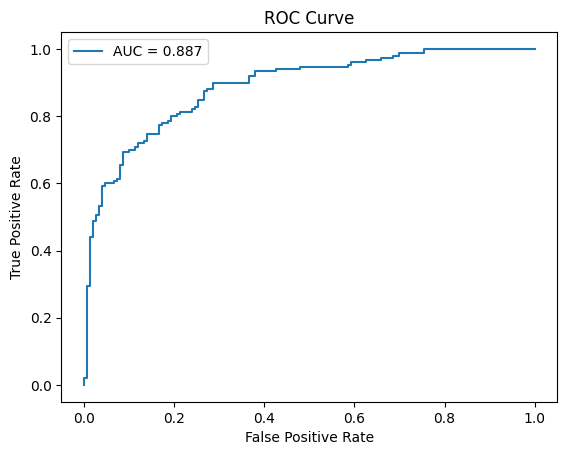

In [ ]:
# ROC Curve with the AUC value
y_scores = model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

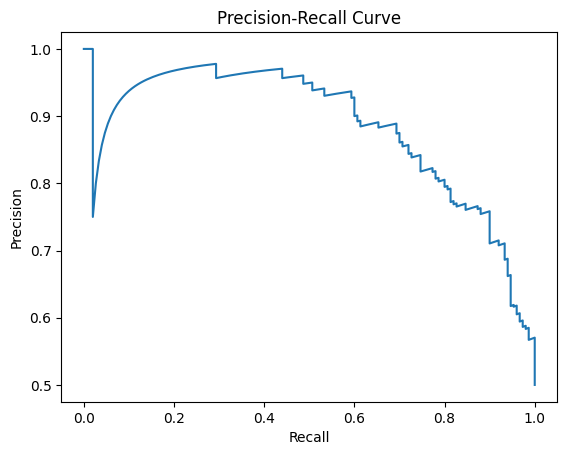

In [ ]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [234]:
# 5-fold Stratified Cross-validation

X_train_val = np.concatenate([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

model = make_model(svm_type = 'linear', penalty = 'l1')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = cross_validate(
    model,
    X_train_val,
    y_train_val,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

f1_scores = results['test_f1']
roc_scores = results['test_roc_auc']

print("F1 Mean:", np.mean(f1_scores))
print("F1 Std:", np.std(f1_scores))

print("ROC-AUC Mean:", np.mean(roc_scores))
print("ROC-AUC Std:", np.std(roc_scores))

F1 Mean: 0.8175030833612164
F1 Std: 0.015849347099750867
ROC-AUC Mean: 0.8936055363321799
ROC-AUC Std: 0.012871254212212252
